# Regresión en BI: Pronóstico de ventas / demanda — FISIMart S.A.C.

Construcción y evaluación de modelos de regresión para pronosticar la venta/demanda diaria de FISIMart, como apoyo a la planificación de inventario y campañas.


#### Celda 0: Librerías y configuración

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
np.random.seed(SEED)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4.5)

pd.set_option("display.max_columns", None)

#### Celda 1: Carga de datos

In [ ]:
ruta = "data/processed/"

fact_ventas = pd.read_csv(ruta + "Fact_Ventas.csv", sep=";", parse_dates=["fecha"])
dim_tiempo  = pd.read_csv(ruta + "Dim_Tiempo.csv", sep=";", parse_dates=["fecha"])
dim_producto = pd.read_csv(ruta + "Dim_Producto.csv", sep=";")
dim_promocion = pd.read_csv(ruta + "Dim_Promocion.csv", sep=";", parse_dates=["fecha_inicio", "fecha_fin"])

print("Fact_Ventas :", fact_ventas.shape)
print("Dim_Tiempo  :", dim_tiempo.shape)
print("Dim_Producto:", dim_producto.shape)
print("Dim_Promocion:", dim_promocion.shape)

fact_ventas.head()

Fact_Ventas : (25413, 12)
Dim_Tiempo  : (731, 7)
Dim_Producto: (600, 7)
Dim_Promocion: (41, 6)


,id_venta,fecha,id_cliente,id_producto,id_tienda,id_promocion,cantidad,precio_unitario,descuento,importe,costo_total,margen
0,VTA000001,2024-01-01,CLI00086,PROD0111,TIE011,PROMO_NONE,1,41.24,0.0,41.24,22.28,18.96
1,VTA000001,2024-01-01,CLI00086,PROD0004,TIE006,PROMO_NONE,1,112.45,0.0,112.45,79.37,33.08
2,VTA000001,2024-01-01,CLI00086,PROD0112,TIE016,PROMO_NONE,1,138.18,0.0,138.18,108.34,29.84
3,VTA000002,2024-01-01,CLI03017,PROD0072,TIE012,PROMO_NONE,2,16.25,0.0,32.50,18.82,13.68
4,VTA000003,2024-01-01,CLI03160,PROD0221,TIE003,PROMO_NONE,1,155.68,0.0,155.68,115.94,39.74


#### Celda 2: Validación rápida de fechas, nulos y duplicados

In [ ]:
# Validación rápida del rango temporal y de calidad (ya deben venir limpios de la Parte 1)
print("Rango de fechas en Fact_Ventas:", fact_ventas["fecha"].min(), "->", fact_ventas["fecha"].max())
print("Nulos por columna:")
print(fact_ventas.isnull().sum())
print("\nDuplicados exactos:", fact_ventas.duplicated().sum())

Rango de fechas en Fact_Ventas: 2024-01-01 00:00:00 -> 2025-12-31 00:00:00
Nulos por columna:
id_venta           0
fecha              0
id_cliente         0
id_producto        0
id_tienda          0
id_promocion       0
cantidad           0
precio_unitario    0
descuento          0
importe            0
costo_total        0
margen             0
dtype: int64

Duplicados exactos: 0


## DEFINICIÓN DE LA VARIABLE OBJETIVO

Se define como objetivo el **importe total de ventas agregado por día** (`ventas_dia`). Trabajar a nivel diario es lo más útil para planificación de inventario y campañas de corto plazo, y da suficientes observaciones (~730 días) para entrenar y validar modelos de series temporales.

Adicionalmente, se agrega la venta diaria **por categoría de producto**, para poder pronosticar la demanda de una categoría específica (ej. "Abarrotes") — esto enriquece el análisis y facilita la página de Power BI de pronóstico por categoría.

#### Celda 3: Unión de Fact_Ventas con la categoría del producto y cálculo de la serie objetivo

In [ ]:
# Unimos Fact_Ventas con la categoría del producto
fact_ventas = fact_ventas.merge(
    dim_producto[["id_producto", "categoria"]],
    on="id_producto", how="left"
)

# --- Serie objetivo principal: ventas totales por día ---
ventas_diarias = (
    fact_ventas.groupby("fecha")
    .agg(ventas=("importe", "sum"),
         unidades=("cantidad", "sum"),
         num_transacciones=("id_venta", "nunique"))
    .reset_index()
)

print("Serie diaria de ventas:", ventas_diarias.shape)
ventas_diarias.head()

Serie diaria de ventas: (731, 4)


,fecha,ventas,unidades,num_transacciones
0,2024-01-01,5157.91,65,22
1,2024-01-02,5052.53,54,19
2,2024-01-03,4555.73,45,19
3,2024-01-04,2864.56,35,15
4,2024-01-05,6414.97,66,22


#### Celda 4: Serie objetivo secundaria: ventas diarias por categoría

In [ ]:
# --- Serie objetivo secundaria: ventas diarias por categoría ---
ventas_categoria_dia = (
    fact_ventas.groupby(["fecha", "categoria"])
    .agg(ventas=("importe", "sum"))
    .reset_index()
)

print("Categorías disponibles:", ventas_categoria_dia["categoria"].unique())
ventas_categoria_dia.head()

Categorías disponibles: ['Abarrotes' 'Bebidas' 'Cuidado Personal' 'Hogar' 'Tecnologia']


,fecha,categoria,ventas
0,2024-01-01,Abarrotes,1180.28
1,2024-01-01,Bebidas,1559.95
2,2024-01-01,Cuidado Personal,1030.43
3,2024-01-01,Hogar,757.86
4,2024-01-01,Tecnologia,629.39


#### Celda 5: Gráfico de la serie diaria de ventas totales

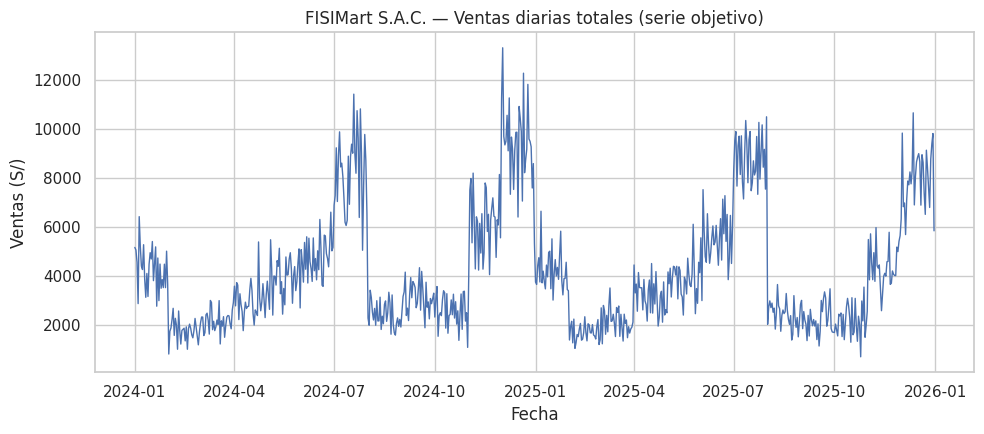

In [ ]:
fig, ax = plt.subplots()
ax.plot(ventas_diarias["fecha"], ventas_diarias["ventas"], linewidth=1)
ax.set_title("FISIMart S.A.C. — Ventas diarias totales (serie objetivo)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Ventas (S/)")
plt.tight_layout()
plt.show()

## CONSTRUCCIÓN DE VARIABLES PREDICTORAS

Se construyen las siguientes familias de variables (*features*) a partir del datamart:

- **Componentes temporales**: día de la semana, mes, trimestre, año, indicador de fin de semana.
- **Estacionalidad**: variables cíclicas (seno/coseno) del día del año y del día de la semana, para que el modelo capture patrones estacionales sin discontinuidades.
- **Feriados**: indicador binario `es_feriado` (viene de `Dim_Tiempo`).
- **Indicador de promoción**: proporción de líneas de venta del día que tuvieron una promoción activa (`PROMO_NONE` = sin promoción).
- **Rezagos (lags)**: ventas de días anteriores (t-1, t-7, t-14) — capturan la dependencia temporal directa.
- **Medias móviles**: promedio de ventas de los últimos 7 y 14 días — suavizan el ruido diario y capturan la tendencia reciente.

Celda 6: Construcción de componentes temporales y de estacionalidad cíclica

In [ ]:
df = dim_tiempo.merge(ventas_diarias, on="fecha", how="left")
df[["ventas", "unidades", "num_transacciones"]] = df[["ventas", "unidades", "num_transacciones"]].fillna(0)

# --- Componentes temporales básicos ---
df["dia_semana_num"] = df["fecha"].dt.dayofweek  # 0=lunes ... 6=domingo
df["es_fin_semana"] = (df["dia_semana_num"] >= 5).astype(int)
df["dia_anio"] = df["fecha"].dt.dayofyear

# --- Estacionalidad cíclica ---
df["mes_sin"] = np.sin(2 * np.pi * df["mes"] / 12)
df["mes_cos"] = np.cos(2 * np.pi * df["mes"] / 12)
df["dia_semana_sin"] = np.sin(2 * np.pi * df["dia_semana_num"] / 7)
df["dia_semana_cos"] = np.cos(2 * np.pi * df["dia_semana_num"] / 7)
df["dia_anio_sin"] = np.sin(2 * np.pi * df["dia_anio"] / 365)
df["dia_anio_cos"] = np.cos(2 * np.pi * df["dia_anio"] / 365)

df.head()

,fecha,dia,mes,trimestre,anio,dia_semana,es_feriado,ventas,unidades,num_transacciones,dia_semana_num,es_fin_semana,dia_anio,mes_sin,mes_cos,dia_semana_sin,dia_semana_cos,dia_anio_sin,dia_anio_cos
0,2024-01-01,1,1,1,2024,Monday,1,5157.91,65,22,0,0,1,0.5,0.866025,0.000000,1.000000,0.017213,0.999852
1,2024-01-02,2,1,1,2024,Tuesday,0,5052.53,54,19,1,0,2,0.5,0.866025,0.781831,0.623490,0.034422,0.999407
2,2024-01-03,3,1,1,2024,Wednesday,0,4555.73,45,19,2,0,3,0.5,0.866025,0.974928,-0.222521,0.051620,0.998667
3,2024-01-04,4,1,1,2024,Thursday,0,2864.56,35,15,3,0,4,0.5,0.866025,0.433884,-0.900969,0.068802,0.997630
4,2024-01-05,5,1,1,2024,Friday,0,6414.97,66,22,4,0,5,0.5,0.866025,-0.433884,-0.900969,0.085965,0.996298


#### Celda 7: Indicador de promoción activa por día

In [ ]:
# --- Indicador de promoción activa por día ---
# Proporción de líneas de venta del día que estuvieron bajo alguna promoción real (distinta de PROMO_NONE)
promo_dia = (
    fact_ventas.assign(con_promo=(fact_ventas["id_promocion"] != "PROMO_NONE").astype(int))
    .groupby("fecha")["con_promo"].mean()
    .reset_index()
    .rename(columns={"con_promo": "pct_lineas_con_promo"})
)

df = df.merge(promo_dia, on="fecha", how="left")
df["pct_lineas_con_promo"] = df["pct_lineas_con_promo"].fillna(0)

df[["fecha", "pct_lineas_con_promo"]].describe()

,fecha,pct_lineas_con_promo
count,731,731.000000
mean,2024-12-31 00:00:00,0.240288
min,2024-01-01 00:00:00,0.000000
25%,2024-07-01 12:00:00,0.000000
50%,2024-12-31 00:00:00,0.294118
75%,2025-07-01 12:00:00,0.456642
max,2025-12-31 00:00:00,0.800000
std,NaN,0.237524


#### Celda 8: Rezagos (lags) y medias móviles de la serie objetivo

In [ ]:
# --- Rezagos (lags) y medias móviles de la serie objetivo ---
df = df.sort_values("fecha").reset_index(drop=True)

df["lag_1"] = df["ventas"].shift(1)
df["lag_7"] = df["ventas"].shift(7)
df["lag_14"] = df["ventas"].shift(14)

df["media_movil_7"] = df["ventas"].shift(1).rolling(window=7).mean()
df["media_movil_14"] = df["ventas"].shift(1).rolling(window=14).mean()

# Los primeros registros no tienen histórico suficiente para calcular lags/medias -> se descartan
df_modelo = df.dropna(subset=["lag_1", "lag_7", "lag_14", "media_movil_7", "media_movil_14"]).reset_index(drop=True)

print("Filas antes de eliminar por falta de histórico:", df.shape[0])
print("Filas disponibles para modelar:", df_modelo.shape[0])
df_modelo.head()

Filas antes de eliminar por falta de histórico: 731
Filas disponibles para modelar: 717


,fecha,dia,mes,trimestre,anio,dia_semana,es_feriado,ventas,unidades,num_transacciones,dia_semana_num,es_fin_semana,dia_anio,mes_sin,mes_cos,dia_semana_sin,dia_semana_cos,dia_anio_sin,dia_anio_cos,pct_lineas_con_promo,lag_1,lag_7,lag_14,media_movil_7,media_movil_14
0,2024-01-15,15,1,1,2024,Monday,0,4943.06,60,22,0,0,15,0.5,0.866025,0.000000,1.000000,0.255353,0.966848,0.463415,4465.44,4255.98,5157.91,4032.702857,4418.984286
1,2024-01-16,16,1,1,2024,Tuesday,0,4686.08,44,19,1,0,16,0.5,0.866025,0.781831,0.623490,0.271958,0.962309,0.352941,4943.06,5268.88,5052.53,4130.857143,4403.637857
2,2024-01-17,17,1,1,2024,Wednesday,0,5399.60,60,22,2,0,17,0.5,0.866025,0.974928,-0.222521,0.288482,0.957485,0.369565,4686.08,3865.22,4555.73,4047.600000,4377.462857
3,2024-01-18,18,1,1,2024,Thursday,0,3801.78,40,16,3,0,18,0.5,0.866025,0.433884,-0.900969,0.304921,0.952378,0.484848,5399.60,3121.96,2864.56,4266.797143,4437.739286
4,2024-01-19,19,1,1,2024,Friday,0,4517.74,43,18,4,0,19,0.5,0.866025,-0.433884,-0.900969,0.321270,0.946988,0.250000,3801.78,4095.58,6414.97,4363.914286,4504.683571


#### Celda 9: Matriz de correlación entre predictoras y ventas

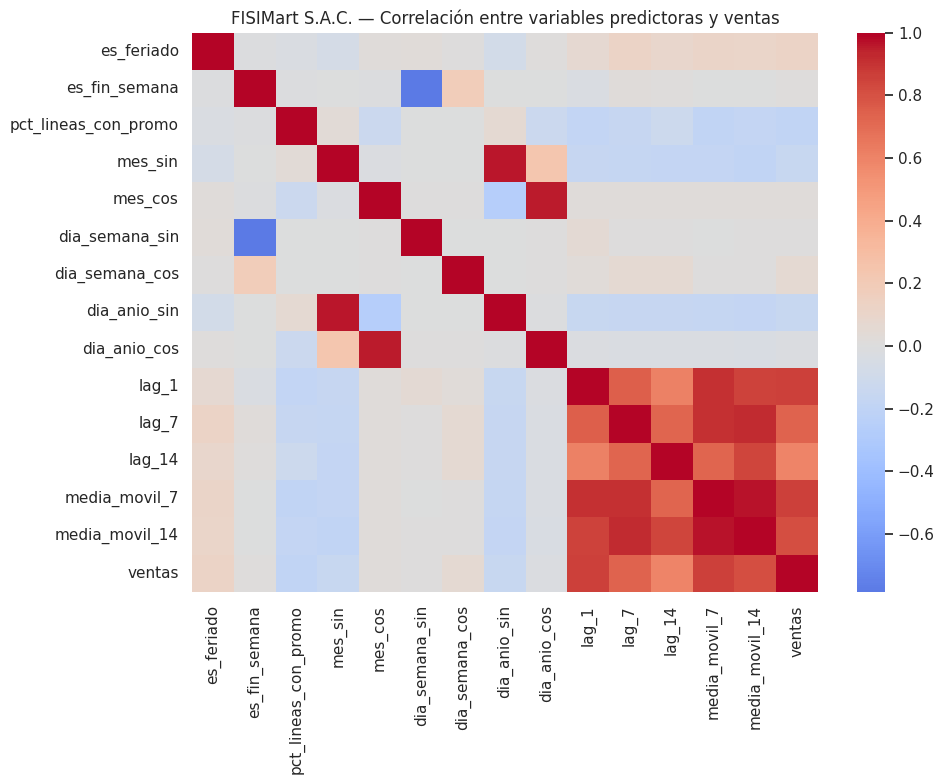

In [ ]:
# Matriz de correlación entre las variables predictoras numéricas y la variable objetivo
features_numericas = [
    "es_feriado", "es_fin_semana", "pct_lineas_con_promo",
    "mes_sin", "mes_cos", "dia_semana_sin", "dia_semana_cos", "dia_anio_sin", "dia_anio_cos",
    "lag_1", "lag_7", "lag_14", "media_movil_7", "media_movil_14", "ventas"
]

plt.figure(figsize=(10, 8))
sns.heatmap(df_modelo[features_numericas].corr(), cmap="coolwarm", center=0, annot=False)
plt.title("FISIMart S.A.C. — Correlación entre variables predictoras y ventas")
plt.tight_layout()
plt.show()

## DIVISIÓN TRAIN / TEST RESPETANDO EL ORDEN TEMPORAL

A diferencia de una división aleatoria, en series de tiempo el conjunto de **prueba debe ser el periodo más reciente**, y el de **entrenamiento el periodo pasado**. Esto evita fuga de información (*data leakage*) desde el futuro hacia el pasado, y simula el escenario real de pronóstico.

Se usa un corte 80/20: se entrena con el primer 80% de los días disponibles y se valida con el 20% más reciente (últimos 2 meses aproximadamente).

#### Celda 10: División train/test respetando el orden temporal

In [ ]:
FEATURES = [
    "es_feriado", "es_fin_semana", "pct_lineas_con_promo",
    "mes_sin", "mes_cos", "dia_semana_sin", "dia_semana_cos", "dia_anio_sin", "dia_anio_cos",
    "lag_1", "lag_7", "lag_14", "media_movil_7", "media_movil_14",
]
TARGET = "ventas"

X = df_modelo[FEATURES]
y = df_modelo[TARGET]
fechas = df_modelo["fecha"]

corte = int(len(df_modelo) * 0.8)  # respeta el orden temporal

X_train, X_test = X.iloc[:corte], X.iloc[corte:]
y_train, y_test = y.iloc[:corte], y.iloc[corte:]
fechas_train, fechas_test = fechas.iloc[:corte], fechas.iloc[corte:]

print(f"Entrenamiento: {X_train.shape[0]} días  ({fechas_train.min().date()} a {fechas_train.max().date()})")
print(f"Prueba       : {X_test.shape[0]} días  ({fechas_test.min().date()} a {fechas_test.max().date()})")

Entrenamiento: 573 días  (2024-01-15 a 2025-08-09)
Prueba       : 144 días  (2025-08-10 a 2025-12-31)


#### Celda 11: Gráfico de la división temporal train/test

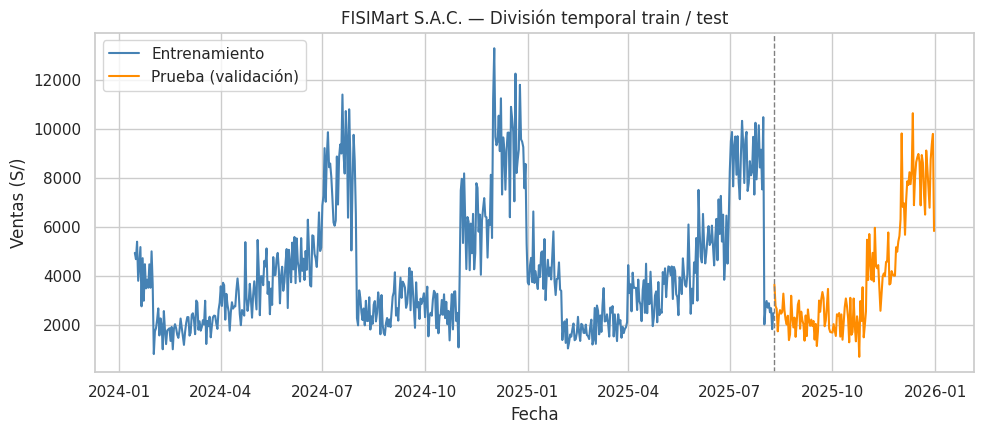

In [ ]:
fig, ax = plt.subplots()
ax.plot(fechas_train, y_train, label="Entrenamiento", color="steelblue")
ax.plot(fechas_test, y_test, label="Prueba (validación)", color="darkorange")
ax.axvline(fechas_test.min(), color="gray", linestyle="--", linewidth=1)
ax.set_title("FISIMart S.A.C. — División temporal train / test")
ax.set_xlabel("Fecha")
ax.set_ylabel("Ventas (S/)")
ax.legend()
plt.tight_layout()
plt.show()

## ENTRENAMIENTO Y COMPARACIÓN DE MODELOS

Se entrenan y comparan tres modelos de regresión:

1. **Regresión Lineal** — modelo base, simple e interpretable.
2. **Random Forest Regressor** — captura relaciones no lineales e interacciones entre variables.
3. **Gradient Boosting Regressor** — modelo de boosting, suele dar el mejor desempeño en series con patrones complejos.

Todos se entrenan con semilla fija (`random_state=42`) para reproducibilidad.

#### Celda 12: Entrenamiento de los tres modelos (Regresión Lineal, Random Forest, Gradient Boosting)

In [ ]:
modelos = {
    "Regresión Lineal": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=SEED),
}

predicciones = {}

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)
    predicciones[nombre] = pred
    print(f"{nombre}: entrenado.")

Regresión Lineal: entrenado.
Random Forest: entrenado.
Gradient Boosting: entrenado.


## EVALUACIÓN DE MODELOS

Se evalúa cada modelo con las métricas estándar de regresión:

- **MAE** (Error Absoluto Medio): error promedio en soles, fácil de interpretar para negocio.
- **RMSE** (Raíz del Error Cuadrático Medio): penaliza más los errores grandes.
- **MAPE** (Error Porcentual Absoluto Medio): error relativo, útil para comparar contra el nivel de ventas.
- **R²**: proporción de la varianza de las ventas explicada por el modelo.

#### Celda 13: Cálculo de métricas de evaluación (MAE, RMSE, MAPE, R²) por modelo

In [ ]:
def calcular_metricas(y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mape = np.mean(np.abs((y_real - y_pred) / y_real)) * 100
    r2 = r2_score(y_real, y_pred)
    return {"MAE": mae, "RMSE": rmse, "MAPE (%)": mape, "R2": r2}

resultados = []
for nombre, pred in predicciones.items():
    metricas = calcular_metricas(y_test.values, pred)
    metricas["Modelo"] = nombre
    resultados.append(metricas)

tabla_metricas = pd.DataFrame(resultados)[["Modelo", "MAE", "RMSE", "MAPE (%)", "R2"]]
tabla_metricas = tabla_metricas.sort_values("RMSE").reset_index(drop=True)
tabla_metricas

,Modelo,MAE,RMSE,MAPE (%),R2
0,Regresión Lineal,727.435869,965.821022,24.960949,0.841675
1,Random Forest,980.199573,1238.887209,32.983178,0.739492
2,Gradient Boosting,1011.319505,1457.284089,30.660037,0.639550


#### Celda 14: Gráfico comparativo de métricas entre modelos

/tmp/ipykernel_3627/3198752786.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tabla_metricas, x="Modelo", y="MAE", ax=axes[0], palette="Blues_d")
/tmp/ipykernel_3627/3198752786.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tabla_metricas, x="Modelo", y="RMSE", ax=axes[1], palette="Oranges_d")
/tmp/ipykernel_3627/3198752786.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tabla_metricas, x="Modelo", y="MAPE (%)", ax=axes[2], palette="Purples_d")
/tmp/ipykernel_3627/3198752786.py:15: FutureWarning: 

Passing `pale

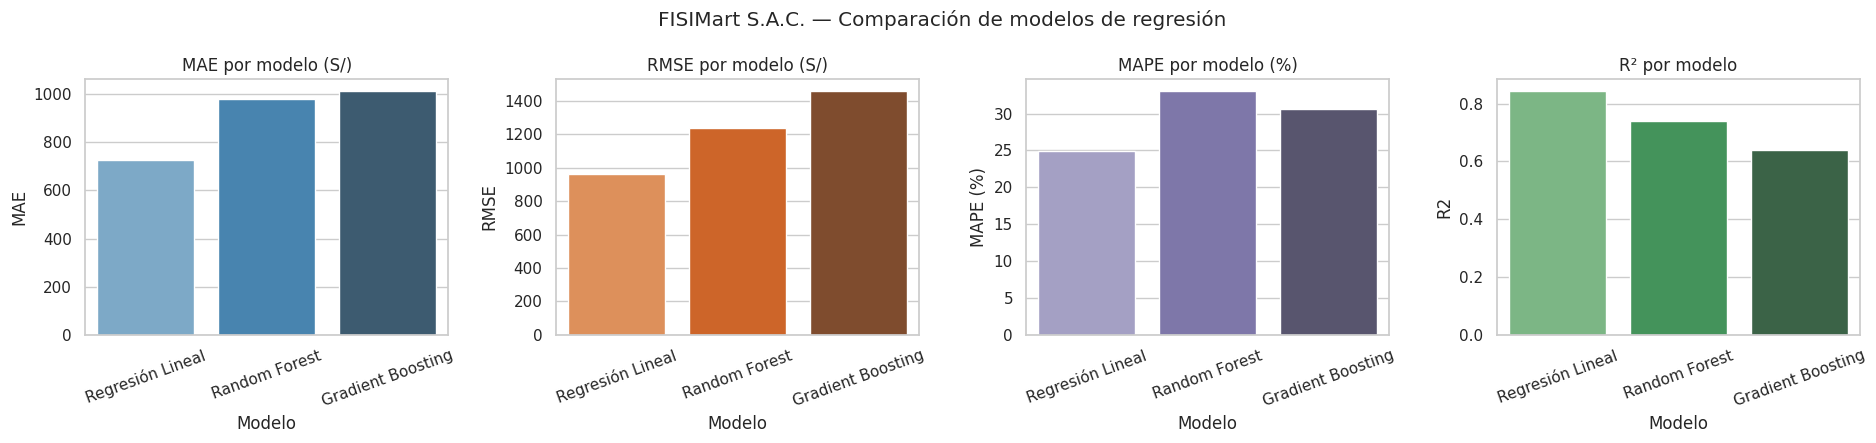

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(19, 4.5))

sns.barplot(data=tabla_metricas, x="Modelo", y="MAE", ax=axes[0], palette="Blues_d")
axes[0].set_title("MAE por modelo (S/)")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=tabla_metricas, x="Modelo", y="RMSE", ax=axes[1], palette="Oranges_d")
axes[1].set_title("RMSE por modelo (S/)")
axes[1].tick_params(axis="x", rotation=20)

sns.barplot(data=tabla_metricas, x="Modelo", y="MAPE (%)", ax=axes[2], palette="Purples_d")
axes[2].set_title("MAPE por modelo (%)")
axes[2].tick_params(axis="x", rotation=20)

sns.barplot(data=tabla_metricas, x="Modelo", y="R2", ax=axes[3], palette="Greens_d")
axes[3].set_title("R² por modelo")
axes[3].tick_params(axis="x", rotation=20)

plt.suptitle("FISIMart S.A.C. — Comparación de modelos de regresión")
plt.tight_layout()
plt.show()

#### Celda 15: Selección del mejor modelo y gráfico real vs. pronóstico

Mejor modelo según RMSE: Regresión Lineal


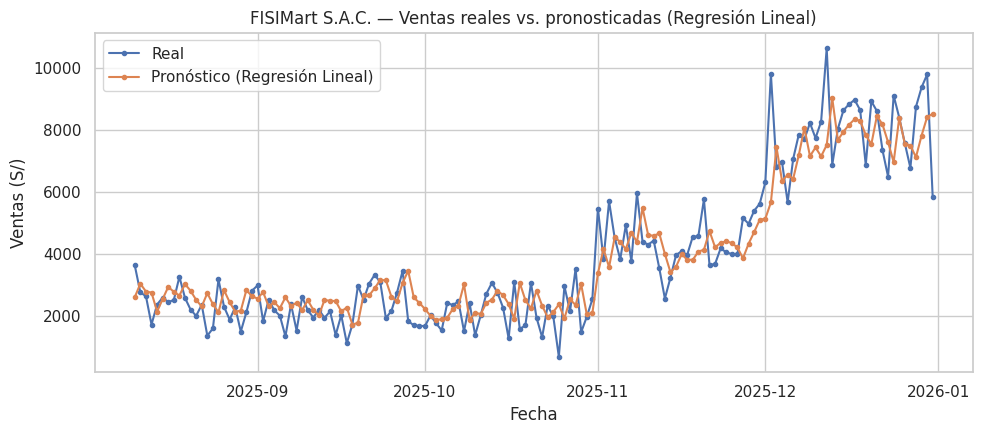

In [ ]:
mejor_modelo_nombre = tabla_metricas.iloc[0]["Modelo"]
print(f"Mejor modelo según RMSE: {mejor_modelo_nombre}")

y_pred_mejor = predicciones[mejor_modelo_nombre]

fig, ax = plt.subplots()
ax.plot(fechas_test, y_test.values, label="Real", marker="o", markersize=3)
ax.plot(fechas_test, y_pred_mejor, label=f"Pronóstico ({mejor_modelo_nombre})", marker="o", markersize=3)
ax.set_title(f"FISIMart S.A.C. — Ventas reales vs. pronosticadas ({mejor_modelo_nombre})")
ax.set_xlabel("Fecha")
ax.set_ylabel("Ventas (S/)")
ax.legend()
plt.tight_layout()
plt.show()

#### Celda 16: Importancia de variables (o coeficientes) del mejor modelo

In [ ]:
# Importancia de variables (aplica a los modelos basados en árboles)
if mejor_modelo_nombre in ["Random Forest", "Gradient Boosting"]:
    importancias = pd.Series(
        modelos[mejor_modelo_nombre].feature_importances_, index=FEATURES
    ).sort_values(ascending=False)

    plt.figure(figsize=(8, 5))
    sns.barplot(x=importancias.values, y=importancias.index, palette="viridis")
    plt.title(f"FISIMart S.A.C. — Importancia de variables ({mejor_modelo_nombre})")
    plt.xlabel("Importancia relativa")
    plt.tight_layout()
    plt.show()
    display(importancias)
else:
    coeficientes = pd.Series(
        modelos[mejor_modelo_nombre].coef_, index=FEATURES
    ).sort_values(key=abs, ascending=False)
    print("Coeficientes del modelo lineal:")
    display(coeficientes)

Coeficientes del modelo lineal:


,0
es_feriado,611.788665
es_fin_semana,308.033654
mes_cos,-216.592148
pct_lineas_con_promo,-160.874996
dia_anio_cos,154.586638
dia_semana_sin,129.342974
dia_semana_cos,125.616139
mes_sin,-60.230484
dia_anio_sin,-56.028365
media_movil_7,0.772292


### Interpretación de negocio

- Los **rezagos** (`lag_1`, `lag_7`) y las **medias móviles** suelen ser las variables más influyentes: las ventas de ayer y de la misma semana anterior son el mejor predictor de las ventas de hoy, lo cual es consistente con el comportamiento habitual de un retail.
- El **fin de semana** y los **feriados** típicamente elevan la demanda, mientras que la **estacionalidad mensual** (capturada por `mes_sin`/`mes_cos`) recoge los picos de julio y diciembre mencionados en la guía del proyecto.
- El **MAPE** obtenido da una noción directa del error relativo esperado, útil para dimensionar el margen de seguridad en la planificación de inventario (por ejemplo, un MAPE de 8% sugiere mantener un colchón de stock proporcional a ese error).
- Estos resultados deben discutirse con el equipo y contrastarse con el conocimiento de negocio antes de usarse para decisiones de compra o campañas.

## EXPORTACIÓN DE RESULTADOS PARA POWER BI

Se exporta la tabla **real vs. pronóstico** del conjunto de prueba (con la predicción del mejor modelo y también de los tres modelos, por transparencia). Esta tabla se importará en Power BI para construir la página **"Pronóstico de demanda"**, mostrando la curva real vs. pronosticada y el MAPE como KPI.

#### Celda 17: Exportación de la tabla real vs. pronóstico a CSV

In [ ]:
tabla_exportar = pd.DataFrame({
    "fecha": fechas_test.values,
    "ventas_real": y_test.values,
    "pronostico_regresion_lineal": predicciones["Regresión Lineal"],
    "pronostico_random_forest": predicciones["Random Forest"],
    "pronostico_gradient_boosting": predicciones["Gradient Boosting"],
    "pronostico_mejor_modelo": y_pred_mejor,
    "modelo_seleccionado": mejor_modelo_nombre,
})
tabla_exportar["error_absoluto"] = (tabla_exportar["ventas_real"] - tabla_exportar["pronostico_mejor_modelo"]).abs()
tabla_exportar["error_pct"] = (tabla_exportar["error_absoluto"] / tabla_exportar["ventas_real"]) * 100

tabla_exportar.to_csv("data/processed/Pronostico_ventas.csv", index=False, sep=";", encoding="utf-8")
print("Archivo exportado: data/processed/Pronostico_ventas.csv")
tabla_exportar.head()


Archivo exportado: data/processed/Pronostico_ventas.csv


,fecha,ventas_real,pronostico_regresion_lineal,pronostico_random_forest,pronostico_gradient_boosting,pronostico_mejor_modelo,modelo_seleccionado,error_absoluto,error_pct
0,2025-08-10,3643.26,2619.223012,2382.775833,2366.707957,2619.223012,Regresión Lineal,1024.036988,28.107711
1,2025-08-11,2771.10,3054.021806,2575.117333,2464.463459,3054.021806,Regresión Lineal,282.921806,10.209729
2,2025-08-12,2651.79,2800.735582,2289.294000,2513.810919,2800.735582,Regresión Lineal,148.945582,5.616794
3,2025-08-13,1735.12,2766.618393,2275.707500,2553.719098,2766.618393,Regresión Lineal,1031.498393,59.448245
4,2025-08-14,2381.60,2153.793924,2511.596200,2514.303581,2153.793924,Regresión Lineal,227.806076,9.565253


#### Celda 18: Exportación de la tabla de métricas a CSV

In [ ]:
# Tabla resumen de métricas también se exporta, para documentar el desempeño del modelo elegido
tabla_metricas.to_csv("data/processed/Metricas_regresion.csv", index=False, sep=";", encoding="utf-8")
print("Archivo exportado: data/processed/Metricas_regresion.csv")
tabla_metricas


Archivo exportado: data/processed/Metricas_regresion.csv


,Modelo,MAE,RMSE,MAPE (%),R2
0,Regresión Lineal,727.435869,965.821022,24.960949,0.841675
1,Random Forest,980.199573,1238.887209,32.983178,0.739492
2,Gradient Boosting,1011.319505,1457.284089,30.660037,0.639550
